In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the datasets
edx = pd.read_csv('data/edx.csv')
udemy = pd.read_csv('data/Udemy.csv')
coursera = pd.read_csv('data/Coursera.csv')
skillshare = pd.read_csv('data/skillshare.csv')


In [2]:
# Helper functions for cleaning
def clean_reviews(x):
    if pd.isna(x): return 0
    x = str(x).lower().replace(',', '').replace(' students', '').strip()
    if 'k' in x:
        try: return float(x.replace('k', '')) * 1000
        except: return 0
    try: return float(x)
    except: return 0

def clean_duration(x):
    if pd.isna(x): return None
    x = str(x).lower()
    if 'total hours' in x:
        return float(x.replace('total hours', '').strip())
    if 'h' in x or 'm' in x:
        h = re.search(r'(\d+)h', x)
        m = re.search(r'(\d+)m', x)
        return (int(h.group(1)) if h else 0) + (int(m.group(1)) if m else 0)/60
    if 'months' in x:
        m_match = re.findall(r'\d+', x)
        if m_match:
            return (sum(map(int, m_match)) / len(m_match)) * 10 # Estimate 10h/month
    return None

def normalize_level(x):
    if pd.isna(x): return 'Unknown'
    x = str(x).lower()
    if 'begin' in x or 'intro' in x: return 'Beginner'
    if 'inter' in x: return 'Intermediate'
    if 'adv' in x or 'expert' in x: return 'Advanced'
    if 'all' in x: return 'All Levels'
    return 'Other'

def count_skills(x):
    if pd.isna(x): return 0
    # Coursera/edX skills are often comma or quote separated
    return len(re.split(r',|"', str(x))) // 2 if '{' in str(x) else len(str(x).split(','))

# Processing Each Platform
# 1. Udemy
udemy_clean = udemy.copy()
udemy_clean['platform'] = 'Udemy'
udemy_clean = udemy_clean.rename(columns={'reviewcount': 'reviews'})
udemy_clean['reviews'] = pd.to_numeric(udemy_clean['reviews'], errors='coerce').fillna(0)
udemy_clean['duration_hours'] = udemy_clean['duration'].apply(clean_duration)
udemy_clean['level'] = udemy_clean['level'].apply(normalize_level)
udemy_clean['num_skills'] = 0

# 2. Coursera
coursera_clean = coursera.copy()
coursera_clean['platform'] = 'Coursera'
coursera_clean = coursera_clean.rename(columns={'course': 'title', 'partner': 'instructor', 'reviewcount': 'reviews'})
coursera_clean['reviews'] = coursera_clean['reviews'].apply(clean_reviews)
coursera_clean['duration_hours'] = coursera_clean['duration'].apply(clean_duration)
coursera_clean['level'] = coursera_clean['level'].apply(normalize_level)
coursera_clean['num_skills'] = coursera_clean['skills'].apply(count_skills)

# 3. Skillshare
skillshare_clean = skillshare.copy()
skillshare_clean['platform'] = 'Skillshare'
skillshare_clean = skillshare_clean.rename(columns={'students': 'reviews'})
skillshare_clean['reviews'] = skillshare_clean['reviews'].apply(clean_reviews)
skillshare_clean['duration_hours'] = skillshare_clean['duration'].apply(clean_duration)
skillshare_clean['rating'] = np.nan
skillshare_clean['level'] = 'Beginner'
skillshare_clean['num_skills'] = 0

# 4. edX
edx_clean = edx.copy()
edx_clean['platform'] = 'edX'
edx_clean = edx_clean.rename(columns={'institution': 'instructor'})
edx_clean['level'] = edx_clean['level'].apply(normalize_level)
edx_clean['reviews'] = 0
edx_clean['rating'] = np.nan
edx_clean['duration_hours'] = np.nan
edx_clean['num_skills'] = edx_clean['associatedskills'].apply(count_skills)

# Merge into a master dataframe
common_cols = ['title', 'instructor', 'rating', 'reviews', 'level', 'platform', 'duration_hours', 'num_skills']
df = pd.concat([
    udemy_clean[common_cols],
    coursera_clean[common_cols],
    skillshare_clean[common_cols],
    edx_clean[common_cols]
], ignore_index=True)

# Feature Engineering
df['title_len'] = df['title'].str.len().fillna(0)

print(f"Total courses combined: {len(df)}")


Total courses combined: 42461


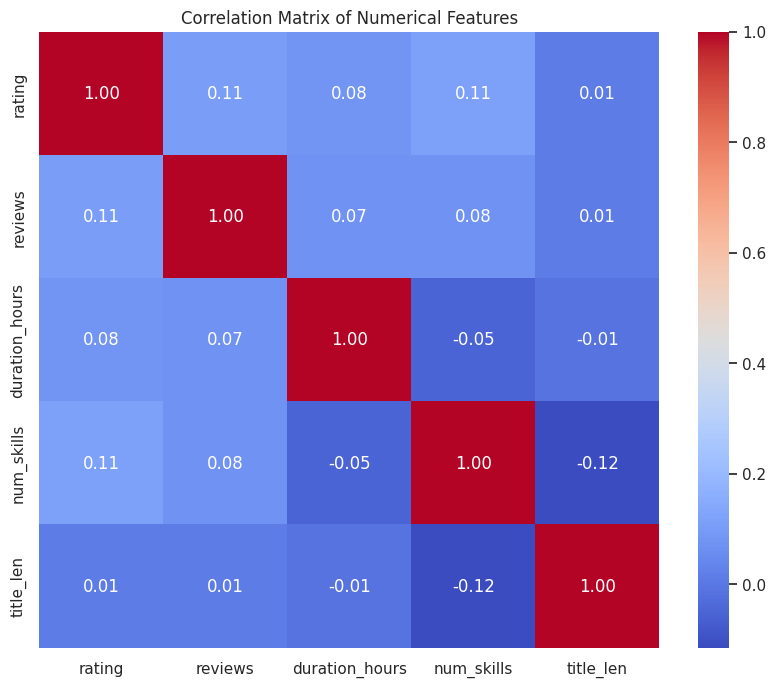

In [3]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


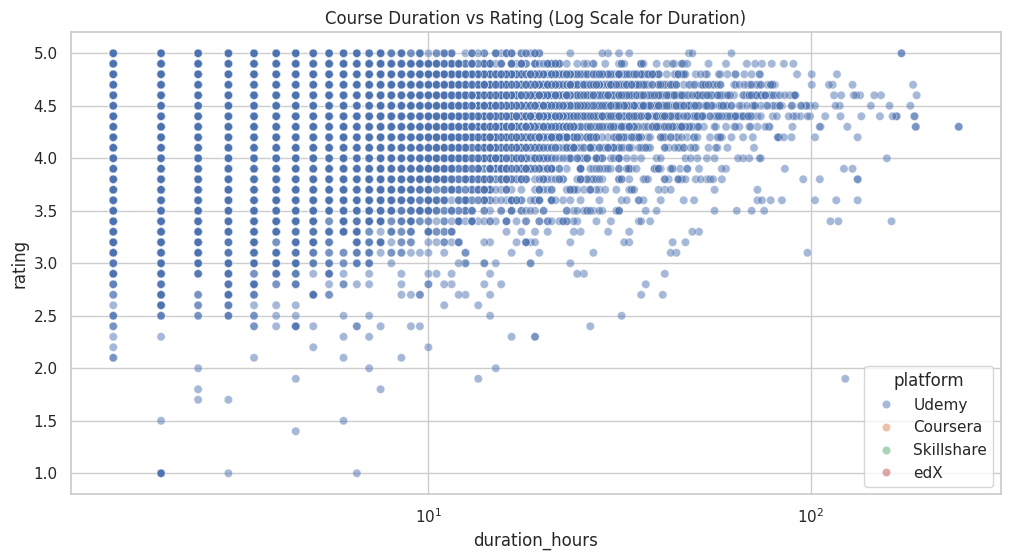

In [4]:
# Duration vs Rating (Scattered with Trend)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='duration_hours', y='rating', hue='platform', alpha=0.5)
plt.title('Course Duration vs Rating (Log Scale for Duration)')
plt.xscale('log')
plt.show()


/tmp/ipykernel_7406/1260300574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[df['rating'].notna()], x='level', y='rating', palette='Pastel1')


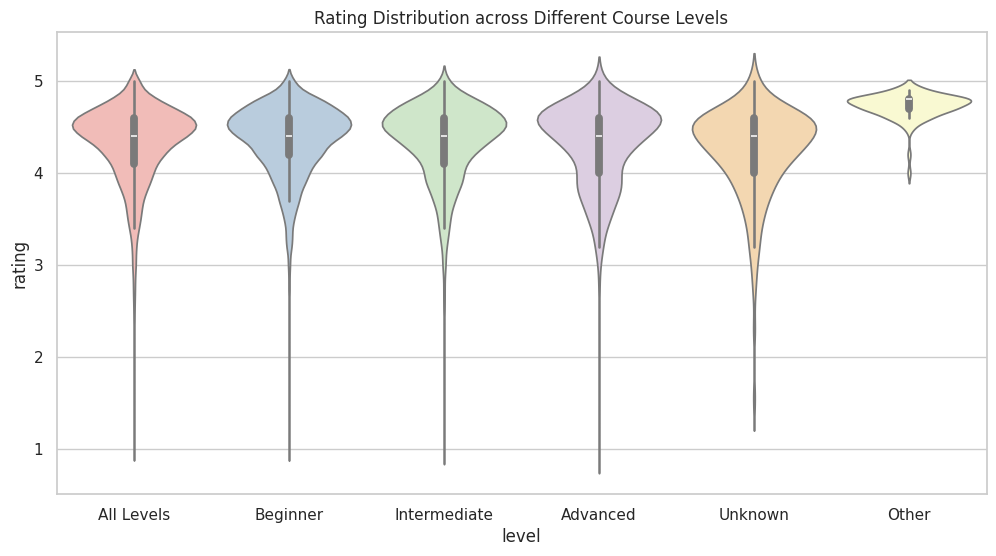

In [5]:
# Level-wise Rating Analysis
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[df['rating'].notna()], x='level', y='rating', palette='Pastel1')
plt.title('Rating Distribution across Different Course Levels')
plt.show()


In [7]:
# 1. Data Preparation
model_df = df[df['rating'].notna() & df['duration_hours'].notna()].copy()

# 2. Encoding categorical variables
le_platform = LabelEncoder()
model_df['platform_enc'] = le_platform.fit_transform(model_df['platform'])

le_level = LabelEncoder()
model_df['level_enc'] = le_level.fit_transform(model_df['level'])

# 3. Features and Target
features = ['platform_enc', 'level_enc', 'duration_hours', 'reviews', 'title_len', 'num_skills']
X = model_df[features]
y = model_df['rating']

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model Training (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluation
y_pred = model.predict(X_test)
print(f"Model R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")


Model R^2 Score: 0.0149
Mean Squared Error: 0.1685


/tmp/ipykernel_7406/3045700631.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette='viridis')


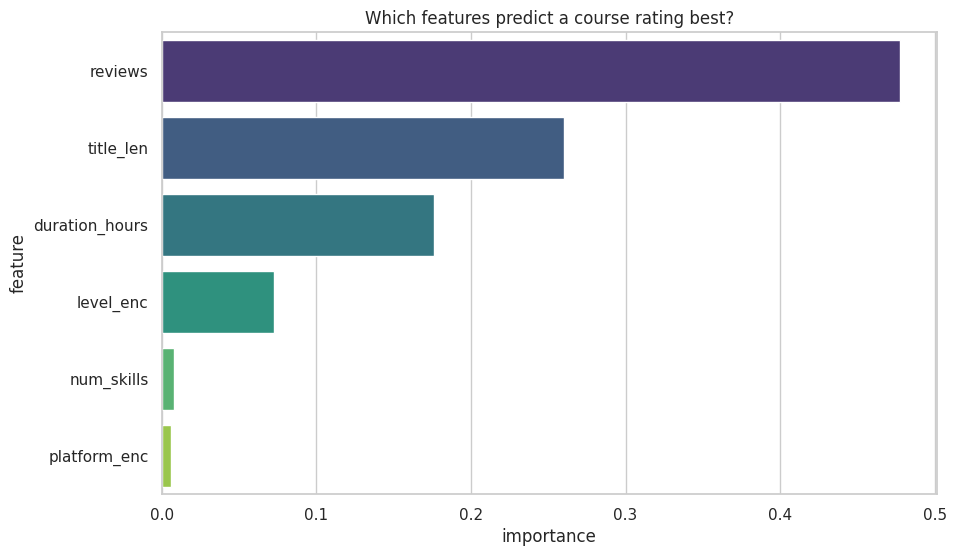

In [8]:
# Feature Importance
importances = pd.DataFrame({'feature': features, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='importance', y='feature', palette='viridis')
plt.title('Which features predict a course rating best?')
plt.show()
